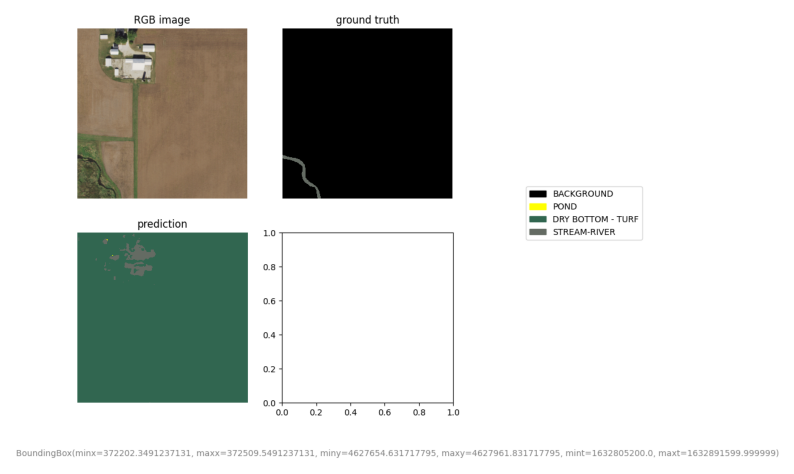

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Path to the PNG file
image_path = "/net/projects/cmap/workspaces/annapoon/point_river_3_trial_0/test-images/epoch-1/STREAM-RIVER/test_sample-1.0.13.png"

# Load and display the image
img = mpimg.imread(image_path)
plt.figure(figsize=(10, 10))  # Set the figure size (width, height)

plt.imshow(img)
plt.axis('off')  # Hide axes for better visualization
plt.show()

In [1]:
# RIVER DATASET
from pathlib import Path
import sys
from rd import RiverDataset
import torch
from torchgeo.datasets import BoundingBox
import sys
import os

# Example configuration for the dataset
rd_configs = (
    {"STREAM-RIVER": 5, "BACKGROUND": 0},  # Label mapping
    256,  # Patch size
    "EPSG:4326",  # Destination CRS
    0.1,  # Resolution in CRS units
)

rd_path = "/net/projects/cmap/data/kane-county-data/Kane_Co_Open_Water_Layer.zip"

# Create RiverDataset instance with both KC and river data
river_dataset = RiverDataset(rd_path, rd_configs, kc=True)

# Access the combined dataset
print(river_dataset.gdf.head())

Loading dataset from cache...
    OBJECTID_1  OBJECTID         FCODE AddUser AddDate      EditUser  \
4            7         7  STREAM-RIVER    None    None          None   
6            9         9  STREAM-RIVER    None    None          None   
23          33        33  STREAM-RIVER    None    None  EDITORGISJCV   
64         106       119  STREAM-RIVER    None    None          None   
65         107       120  STREAM-RIVER    None    None          None   

      EditDate    Shape_STAr     Shape_STLe  \
4         None  1.172604e+04    1275.191296   
6         None  2.128186e+05   19090.189595   
23  2023-06-26  8.174566e+07  680059.514125   
64        None  3.944582e+03     497.472119   
65        None  1.295572e+03     173.314525   

                                             geometry     BasinType  
4   POLYGON ((-88.26169 41.73687, -88.26169 41.736...  STREAM-RIVER  
6   POLYGON ((-88.28127 41.72802, -88.28127 41.728...  STREAM-RIVER  
23  POLYGON ((-88.33520 41.93227, -88.33520 

In [3]:
len(river_dataset)

184

RTreeError: Coordinates must not have minimums more than maximums

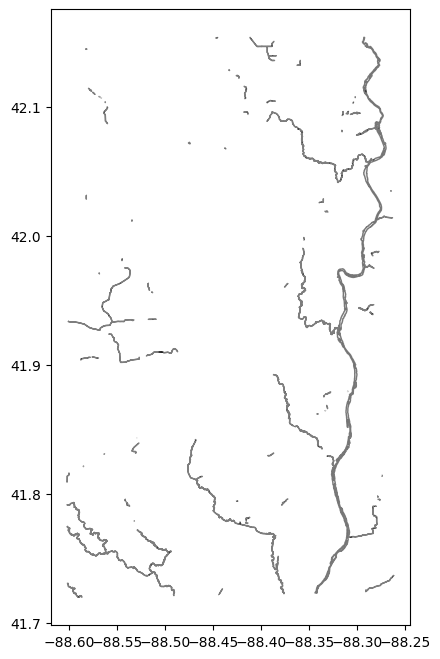

In [2]:
import matplotlib.pyplot as plt
from shapely.geometry import box

# Create a new figure
fig, ax = plt.subplots(figsize=(8, 8))  # Adjust the second value to make it taller

# Plot the geometries in river_dataset.gdf
# Assuming 'geometry' column contains geometries of the river polygons
river_dataset.gdf.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5)

# Initialize the river counter
river_counter = 0

# Initialize limits for plotting based on chips
minx_plot, miny_plot, maxx_plot, maxy_plot = float('inf'), float('inf'), -float('inf'), -float('inf')

# Loop through the R-tree index and extract bounding box coordinates
for item in river_dataset.index.intersection(river_dataset.index.bounds, objects=True):
    # Check the structure of item.bbox to understand the extra values
    #print(f"Item BBox: {item.bbox}")
    
    # Assuming bbox contains extra data, extracting the expected (minx, maxx, miny, maxy) values
    # Accessing the coordinates according to your custom index structure
    minx, maxx, miny, maxy = item.bbox[0], item.bbox[1], item.bbox[3], item.bbox[4]
    bbox = [minx, miny, maxx, maxy]
    
    # Ensure bbox has valid coordinates (minx, miny, maxx, maxy)
    if len(bbox) == 4:
        # Update plot limits dynamically based on chip bounding boxes
        minx_plot = min(minx_plot, minx)
        miny_plot = min(miny_plot, miny)
        maxx_plot = max(maxx_plot, maxx)
        maxy_plot = max(maxy_plot, maxy)
        
        # Create a rectangle (chip) for the bounding box using Shapely
        chip = box(minx, miny, maxx, maxy)  # Create a chip using the custom bounding box
        
        # Extract the exterior coordinates of the chip (polygon)
        x, y = chip.exterior.xy
        
        # Plot the bounding box
        ax.plot(x, y, 'b-', lw=1, alpha=0.1)  # Plot using the exterior coordinates
        
        # Increment the counter
        river_counter += 1
    else:
        print(f"Skipping item with invalid bbox: {bbox}")

# Set plot limits based on the min/max of the bounding boxes
print(f"Setting plot limits: minx={minx_plot}, miny={miny_plot}, maxx={maxx_plot}, maxy={maxy_plot}")
ax.set_xlim(minx_plot, maxx_plot)
ax.set_ylim(miny_plot, maxy_plot)

# Double-check the limits to make sure they're correct:
print(f"Plot X Limits: {ax.get_xlim()}")
print(f"Plot Y Limits: {ax.get_ylim()}")

# Add titles and labels
ax.set_title(f"River and KC Chips ({river_counter} chips)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Show the plot
plt.show()

# Print the total number of chips
print("river chip count:", river_counter)
    

In [1]:
#import torch
from torchgeo.datasets import BoundingBox
from kc import KaneCounty
import sys
import os

# Load the configuration settings
DATA_ROOT = "/net/projects/cmap/data"
KC_SHAPE_ROOT = os.path.join(DATA_ROOT, "kane-county-data")
KC_SHAPE_FILENAME = "KC_StormwaterDataJan2024.gdb.zip"  # Filename from config
KC_LAYER = 4  # Layer number from config
KC_LABELS = {
    "BACKGROUND": 0,
    "POND": 1,
    "WETLAND": 2,
    "DRY BOTTOM - TURF": 3,
    "DRY BOTTOM - MESIC PRAIRIE": 4,
}

# Assume the full path to the GeoPackage
path = os.path.join(KC_SHAPE_ROOT, KC_SHAPE_FILENAME)

# Configuration for the dataset
labels = KC_LABELS
patch_size = 256  # Size of the patches to be extracted
dest_crs = "EPSG:4326"  # Desired Coordinate Reference System (WGS84)
resolution = 0.0001  # Spatial resolution of the dataset


# Update configs to include the layer name
configs = (KC_LAYER, labels, patch_size, dest_crs, resolution)

# Create an instance of the KaneCounty dataset
kc_dataset = KaneCounty(path, configs)

# Example bounding box query (minx, maxx, miny, maxy, mint, maxt)
# Adjusted to fit within the dataset bounds
bbox = BoundingBox(
    minx=-89.6,       # Adjusted within the dataset minx
    maxx=-87.2,       # Adjusted within the dataset maxx
    miny=40.72,       # Adjusted within the dataset miny
    maxy=43.18,       # Adjusted within the dataset maxy
    mint=0,           # Optional: you can leave this as is
    maxt=sys.maxsize  # Optional: you can leave this as is
)

# Fetch data for this bounding box
try:
    sample = kc_dataset[bbox]  # Fetch sample for the bounding box
    # Print the sample (mask, CRS, bounding box)
    print("Mask shape:", sample['mask'].shape)
    print("CRS:", sample['crs'])
    print("Bounding Box:", sample['bbox'])
except IndexError as e:
    print(f"Error: {e}")

context_size: 1
patch_size: 256
res: 0.0001
Mask shape: torch.Size([24600, 24000])
CRS: EPSG:4326
Bounding Box: BoundingBox(minx=-89.6, maxx=-87.2, miny=40.72, maxy=43.18, mint=0, maxt=9223372036854775807)


In [2]:
len(kc_dataset.gdf)

5189